# Sesión 1 — Del Dato a la Tarifa: Tu Primer GLM en Python
## Módulo 4 · Tema 2: GLM con Python
### Diplomado: Machine Learning en Seguros · FC UNAM
### 22 de agosto de 2026  ·  4 horas

---

> **Premisa:** recibes la cartera de autos ya limpia (163,212 pólizas). Hoy ajustas tu
> primer **GLM de frecuencia** con rigor: entiendes qué distribución elegir y por qué,
> validas cada supuesto con su prueba formal, y demuestras que el GLM **no es magia** —
> reproduce el cálculo actuarial exacto y lo generaliza a muchas variables a la vez.

---

**Prerequisito:** debe existir `datos/datos.pkl`. Ambiente `conda` **diplomado**
con `statsmodels`, `pandas`, `numpy`, `matplotlib`, `scipy`.

Las soluciones a los ejercicios 📝 viven en `m4t2_s1_soluciones.py`, **no** en este notebook.

## Ruta de la sesión — seis bloques

| # | Bloque | Idea central |
|---|--------|--------------|
| 1 | El menú del GLM en pricing | ¿Qué error puedo modelar? Frecuencia, severidad, agregado |
| 2 | EDA empírica + el problema de los bandings | La tasa empírica con IC · por qué los cortes son criterio propio |
| 3 | Exposición y censura | Los datos de seguros son censurados · offset vs weights |
| 4 | Ajuste y el puente empírico | El GLM **reproduce** la tasa empírica · construir el modelo |
| 5 | El supuesto de Poisson y las alternativas | De $s^2/\bar m$ a $\varphi$ · Cameron-Trivedi · QuasiPoisson, ZIP, Hurdle, BN |
| 6 | Leer el `summary()` + Python vs R | El output número por número · el mismo modelo en R |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

# Paleta del diplomado (misma que las slides)
AZUL='#0D7A8A'; AMBAR='#F4A261'; GRIS='#8FA3B1'; MORADO='#B07CC6'; VERDE='#2ECC71'
plt.rcParams.update({'figure.figsize':(10,5),'axes.grid':True,'grid.alpha':0.25,'axes.axisbelow':True})
pd.set_option('display.float_format','{:,.4f}'.format); pd.set_option('display.max_columns',25)

datos = pd.read_pickle('datos/datos.pkl')

# Referencias globales que usaremos todo el día
freq_ref = datos['num_siniestros'].sum() / datos['exposicion'].sum()
sev_ref  = np.average(datos.loc[datos.num_siniestros>0,'severidad'],
                      weights=datos.loc[datos.num_siniestros>0,'num_siniestros'])
print(f'Pólizas: {len(datos):,}')
print(f'Frecuencia de referencia: {freq_ref:.4%}')
print(f'Severidad de referencia:  ${sev_ref:,.0f}')
datos.head(3)

Pólizas: 163,212
Frecuencia de referencia: 13.9206%
Severidad de referencia:  $1,309


,id_poliza,exposicion,num_siniestros,tiene_siniestro,monto_total,severidad,cobertura,sexo,edad_conductor,uso,flotilla,combustible,potencia,antiguedad_vehiculo,nivel_bonus,codigo_postal,longitud,latitud
0,1,1.0000,1,1,"1,618.0010","1,618.0010",RC,Hombre,50.0000,Particular,No,Gasolina,77.0000,12.0000,5.0000,1000,4.3552,50.8454
1,2,1.0000,0,0,0.0000,NaN,Limitada,Mujer,64.0000,Particular,No,Gasolina,66.0000,3.0000,5.0000,1000,4.3552,50.8454
2,3,1.0000,0,0,0.0000,NaN,RC,Hombre,60.0000,Particular,No,Diesel,70.0000,10.0000,0.0000,1000,4.3552,50.8454


---
# Bloque 1 · El menú del GLM en pricing

El marco formal del GLM (familia exponencial, forma canónica, función liga) ya lo
cubrió otro módulo — aquí solo lo usamos. Lo que **sí** nos importa hoy es la
decisión práctica: **¿qué distribución del error elijo, y qué implica esa elección
para la tarifa?**

Un GLM tiene tres componentes: (1) el **error aleatorio** $Y_i$ con una distribución
de la familia exponencial; (2) el **predictor lineal** $\eta_i=\mathbf{x}_i'\boldsymbol\beta$;
(3) la **liga** $g(\mu_i)=\eta_i$. Lo que caracteriza a cada distribución es su
**función de varianza** $V(\mu)$, que dice cómo crece la varianza con la media:

$$\text{Var}[Y_i] = \phi\, V(\mu_i).$$

### El menú, leído como decisión de pricing

| Distribución | $V(\mu)$ | Rol en pricing | Cuándo |
|---|---|---|---|
| **Poisson** | $\mu$ | **Frecuencia** | conteo de siniestros; equidispersión |
| QuasiPoisson | $\phi\mu$ | Frecuencia | sobredispersión leve (ajusta errores) |
| Binomial Negativa | $\mu+\mu^2/\alpha$ | Frecuencia | heterogeneidad no observada |
| ZIP / Hurdle | mezcla | Frecuencia | exceso de ceros estructurales |
| **Gamma** | $\mu^2$ | **Severidad** | monto por siniestro; CV constante |
| Gaussiana Inversa | $\mu^3$ | Severidad | colas más pesadas |
| **Tweedie** | $\mu^{p},\,1<p<2$ | **Prima pura (agregado)** | modela `amount/expo` directo, con ceros |

**Qué implica la elección.** El enfoque clásico separa **Frecuencia × Severidad**
(dos GLM, dos juegos de rating factors, máxima trazabilidad para nota técnica CNSF).
El enfoque **Tweedie** modela la prima pura de un jalón (un solo modelo, útil como
benchmark). Hoy nos quedamos en **frecuencia con Poisson**; severidad (Gamma) y el
agregado (Tweedie) son la Sesión 2.

### La liga log convierte todo en multiplicativo

Con $g=\log$: $\ \log(\mu_i)=\beta_0+\beta_1x_{1i}+\cdots\ $ implica
$$\mu_i=e^{\beta_0}\cdot e^{\beta_1 x_{1i}}\cdot e^{\beta_2 x_{2i}}\cdots$$
Cada $e^{\beta_j}$ es un **rating factor**: $e^{\beta_0}$ es la prima base (categoría de
referencia) y cada factor recarga ($>1$) o descuenta ($<1$). Y como toda tarifa a nota
técnica necesita respaldo, cada factor va con su **intervalo de confianza**
$\exp(\hat\beta_j \pm 1.96\,\widehat{\text{SE}}_j)$.

---
# Bloque 2 · EDA empírica + el problema de los bandings

Antes de cualquier modelo, la pregunta actuarial es simple: **¿cuál es la tasa de
siniestralidad observada por grupo?** La tasa empírica ponderada por exposición de un
grupo $g$ es
$$\widehat{\text{freq}}_g=\frac{\sum_{i\in g} n_i}{\sum_{i\in g} e_i}.$$
No basta el punto: necesitamos su **incertidumbre**. Tratando los siniestros del grupo
como Poisson, un intervalo aproximado al 95% es
$$\widehat{\text{freq}}_g \;\pm\; 1.96\,\frac{\sqrt{s^2_g}}{\sqrt{\sum_{i\in g} e_i}},$$
donde $s^2_g$ es la varianza ponderada de la frecuencia dentro del grupo.

In [2]:
def tasa_empirica(df, variable, min_expo=0):
    # Tasa de siniestralidad ponderada por exposición, con IC 95% e info de exposición
    g = df.groupby(variable, observed=True)
    out = g.apply(lambda x: pd.Series({
        'expo':  x['exposicion'].sum(),
        'sinis': x['num_siniestros'].sum(),
        'freq':  x['num_siniestros'].sum() / x['exposicion'].sum(),
        's2':    np.average((x['num_siniestros']/x['exposicion'] -
                             x['num_siniestros'].sum()/x['exposicion'].sum())**2,
                            weights=x['exposicion']),
    }), include_groups=False).reset_index()
    out['ic'] = 1.96 * np.sqrt(out['s2']) / np.sqrt(out['expo'])
    return out[out['expo'] >= min_expo]

# Ejemplo: cobertura
te_cob = tasa_empirica(datos, 'cobertura')
print(te_cob.round(4).to_string(index=False))

cobertura        expo       sinis   freq     s2     ic
   Amplia 19,786.2164  2,675.0000 0.1352 0.1614 0.0056
 Limitada 41,676.4466  5,322.0000 0.1277 0.1647 0.0039
       RC 83,754.1616 12,218.0000 0.1459 0.2134 0.0031


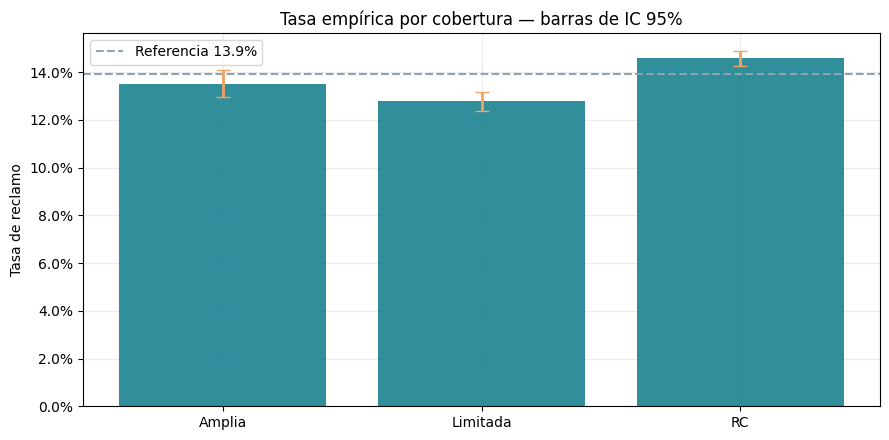

In [3]:
def plot_tasa(te, variable, titulo):
    fig, ax = plt.subplots(figsize=(9,4.5))
    x = np.arange(len(te))
    ax.bar(x, te['freq'], color=AZUL, alpha=0.85, zorder=2)
    ax.errorbar(x, te['freq'], yerr=te['ic'], fmt='none', ecolor=AMBAR, elinewidth=2, capsize=5, zorder=3)
    ax.axhline(freq_ref, ls='--', color=GRIS, label=f'Referencia {freq_ref:.1%}')
    ax.set_xticks(x); ax.set_xticklabels(te[variable].astype(str), rotation=0)
    ax.set(ylabel='Tasa de reclamo', title=titulo)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.1%}'))
    ax.legend(); plt.tight_layout(); plt.show()

plot_tasa(te_cob, 'cobertura', 'Tasa empírica por cobertura — barras de IC 95%')

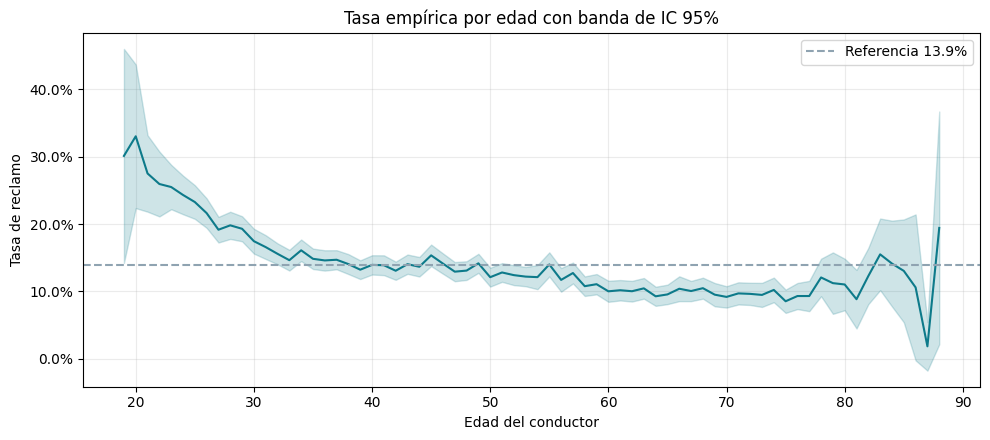

In [4]:
# ── EDA de una variable continua: tasa por edad, punto a punto con su IC ──────
te_edad = tasa_empirica(datos, 'edad_conductor')
te_edad = te_edad[te_edad['expo'] > 50]  # descartamos edades con muy poca exposición
fig, ax = plt.subplots(figsize=(10,4.5))
ax.plot(te_edad['edad_conductor'], te_edad['freq'], color=AZUL, lw=1.5, zorder=2)
ax.fill_between(te_edad['edad_conductor'], te_edad['freq']-te_edad['ic'],
                te_edad['freq']+te_edad['ic'], color=AZUL, alpha=0.2, zorder=1)
ax.axhline(freq_ref, ls='--', color=GRIS, label=f'Referencia {freq_ref:.1%}')
ax.set(xlabel='Edad del conductor', ylabel='Tasa de reclamo',
       title='Tasa empírica por edad con banda de IC 95%')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.1%}'))
ax.legend(); plt.tight_layout(); plt.show()

### 📝 Ejercicio 1 — La tasa empírica de otra variable (8 min)

- **1a.** Calcula la tasa empírica con IC 95% para `nivel_bonus` usando `tasa_empirica`.
- **1b.** Grafícala. ¿La tendencia tiene sentido actuarial (más bonus-malus, más riesgo)?
- **1c.** ¿En qué niveles el IC es más ancho y por qué?

*Solución en `solucion_ejercicio1()`.*

In [ ]:
# Tu código aquí:


### El gran problema del pricing: los bandings son criterio propio

La curva de arriba es continua y ruidosa. Para meterla a un GLM la **categorizamos**
en bandas (`bandings`). Y aquí está uno de los problemas de fondo del pricing clásico:
**no existe una regla que te diga dónde cortar.** Los cortes se eligen a criterio del
actuario, balanceando dos fuerzas opuestas:

- **Resolución** — más bandas capturan mejor la forma de la curva.
- **Estabilidad** — cada banda necesita **suficiente exposición** para que su tasa no
  sea puro ruido.

No hay un óptimo cerrado. Encontrar el mejor punto de corte es precisamente lo que
más adelante resolveremos con **ML** (árboles, GAMs, penalización): algoritmos que
*aprenden* los cortes en lugar de imponerlos a mano. Por hoy, exploramos a criterio.

In [5]:
# ── Exploración de bandings: el trade-off resolución vs exposición ───────────
def resumen_banding(cortes):
    cat = pd.cut(datos['edad_conductor'], bins=cortes)
    r = datos.groupby(cat, observed=True).agg(
        expo=('exposicion','sum'), sinis=('num_siniestros','sum')).reset_index()
    r['freq'] = r['sinis'] / r['expo']
    return r

candidatos = {
    'Grueso (4 bandas)':  [17, 30, 50, 70, 95],
    'Medio (7 bandas)':   [17, 30, 35, 45, 50, 55, 60, 95],
    'Fino (10 bandas)':   [17, 25, 30, 35, 40, 45, 50, 55, 60, 70, 95],
}
for nombre, cortes in candidatos.items():
    r = resumen_banding(cortes)
    print(f'\n{nombre}: exposición mínima por banda = {r["expo"].min():,.0f} años-póliza')
    print(r[['edad_conductor','expo','freq']].round(4).to_string(index=False))


Grueso (4 bandas): exposición mínima por banda = 11,629 años-póliza
edad_conductor        expo   freq
      (17, 30] 20,899.6027 0.2134
      (30, 50] 66,868.6384 0.1420
      (50, 70] 45,819.6685 0.1112
      (70, 95] 11,628.9151 0.1001

Medio (7 bandas): exposición mínima por banda = 11,343 años-póliza
edad_conductor        expo   freq
      (17, 30] 20,899.6027 0.2134
      (30, 35] 15,788.2521 0.1553
      (35, 45] 33,947.3644 0.1405
      (45, 50] 17,133.0219 0.1328
      (50, 55] 14,132.1370 0.1267
      (55, 60] 11,343.3205 0.1131
      (60, 95] 31,973.1260 0.0996

Fino (10 bandas): exposición mínima por banda = 7,076 años-póliza
edad_conductor        expo   freq
      (17, 25]  7,075.5233 0.2516
      (25, 30] 13,824.0795 0.1939
      (30, 35] 15,788.2521 0.1553
      (35, 40] 16,781.0959 0.1410
      (40, 45] 17,166.2685 0.1400
      (45, 50] 17,133.0219 0.1328
      (50, 55] 14,132.1370 0.1267
      (55, 60] 11,343.3205 0.1131
      (60, 70] 20,344.2110 0.0993
      (70, 95]

### 📝 Ejercicio 2 — Elige un banding y defiéndelo (10 min)

- **2a.** Propón un banding para `potencia` (caballos de fuerza).
- **2b.** Reporta la exposición mínima por banda: ¿alguna banda queda con < 1% de la
  exposición total? Si sí, ajústala.
- **2c.** En una frase: ¿qué criterio usaste para cortar y qué perderías con un banding
  más fino?

*Solución en `solucion_ejercicio2()`.*

In [ ]:
# Tu código aquí:


---
# Bloque 3 · Exposición y censura

Un dato incómodo pero central: **los datos de seguros son censurados**. Casi ninguna
póliza se observa el año completo — entra a mitad de año, se cancela, se endosa. Si una
póliza estuvo vigente $e_i=0.5$ años, solo observamos **medio año** de su
comportamiento: es una observación **parcial** de su conteo anual de siniestros.

La **exposición** $e_i$ cuantifica esa observación parcial. Ignorarla sesga todo: una
póliza de medio año con 0 siniestros no es lo mismo que una de un año con 0 siniestros.

Exposición: mín=0.003, máx=1.000
Pólizas con menos de un año de exposición: 22.7%


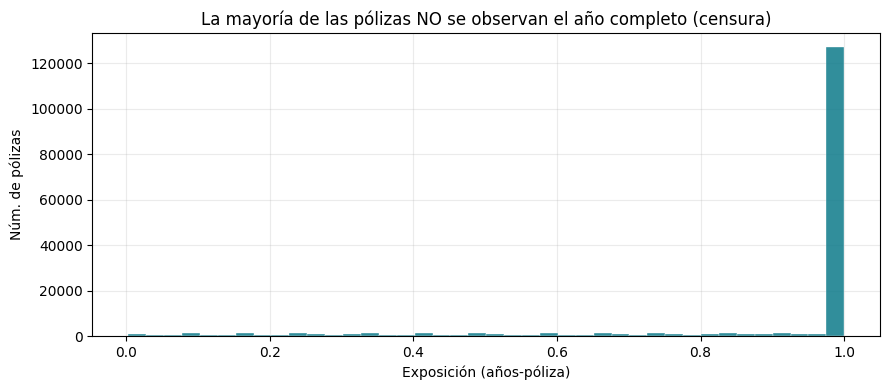

In [6]:
# ── ¿Qué tan censurada está la cartera? ──────────────────────────────────────
print(f'Exposición: mín={datos.exposicion.min():.3f}, máx={datos.exposicion.max():.3f}')
print(f'Pólizas con menos de un año de exposición: {(datos.exposicion < 1).mean():.1%}')
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(datos['exposicion'], bins=40, color=AZUL, alpha=0.85, edgecolor='white', linewidth=0.3)
ax.set(xlabel='Exposición (años-póliza)', ylabel='Núm. de pólizas',
       title='La mayoría de las pólizas NO se observan el año completo (censura)')
plt.tight_layout(); plt.show()

### Cómo se resuelve: modelamos el conteo con la media escalada por exposición

El modelo correcto no es $N_i\sim\text{Poisson}(\lambda_i)$ sino
$$N_i \sim \text{Poisson}(e_i\,\lambda_i),\qquad \log(e_i\lambda_i)=\log(e_i)+\mathbf{x}_i'\boldsymbol\beta.$$
El término $\log(e_i)$ entra con **coeficiente fijo en 1**: eso es un **offset**. Hay dos
implementaciones equivalentes:

- **Offset** — modelas el conteo $N_i$ y pasas $\log(e_i)$ como desplazamiento.
- **Weights** — modelas la frecuencia $N_i/e_i$ y pasas $e_i$ como peso.

Dan los **mismos coeficientes**; lo comprobamos en el siguiente bloque.

---
# Bloque 4 · Ajuste y el puente empírico

### El GLM no es magia: reproduce el cálculo exacto

Antes de confiar en el GLM, hay que **ver** que no inventa nada. Las ecuaciones de
verosimilitud (score) de un Poisson con liga log obligan a que, para cada nivel de una
categórica, la suma de predichos iguale la suma de observados:
$$\sum_{i\in g} n_i = \sum_{i\in g}\hat\mu_i = \sum_{i\in g} e_i\,e^{\hat\eta_g}
\;\Longrightarrow\; e^{\hat\eta_g}=\frac{\sum_{i\in g} n_i}{\sum_{i\in g} e_i}=\widehat{\text{freq}}_g.$$
Es decir: en un modelo **one-way**, la tasa ajustada por el GLM **es** la tasa empírica
ponderada, al centavo. La base $e^{\hat\beta_0}$ es la tasa del nivel de referencia, y
$\text{base}\times RF_g$ reconstruye la tasa de $g$.

In [7]:
# ── Demostración: base × RF (GLM one-way) == tasa empírica ───────────────────
m_ow = smf.glm('num_siniestros ~ C(cobertura)', datos,
               family=sm.families.Poisson(), offset=np.log(datos['exposicion'])).fit()

base = np.exp(m_ow.params['Intercept'])
niveles = datos['cobertura'].cat.categories if hasattr(datos['cobertura'],'cat') else sorted(datos['cobertura'].unique())
ref = [n for n in niveles if f'C(cobertura)[T.{n}]' not in m_ow.params.index][0]

filas = []
for n in niveles:
    term = f'C(cobertura)[T.{n}]'
    rf = 1.0 if n == ref else np.exp(m_ow.params[term])
    tasa_glm = base * rf
    tasa_emp = datos.loc[datos.cobertura==n,'num_siniestros'].sum() / datos.loc[datos.cobertura==n,'exposicion'].sum()
    filas.append({'cobertura':n, 'RF':rf, 'tasa_glm':tasa_glm, 'tasa_empirica':tasa_emp,
                  'diferencia':abs(tasa_glm-tasa_emp)})
comp = pd.DataFrame(filas)
print(f'Categoría de referencia: {ref}  (RF = 1 por definición)\n')
print(comp.to_string(index=False, float_format=lambda v: f'{v:,.8f}'))
print(f'\nDiferencia máxima: {comp["diferencia"].max():.2e}  →  el GLM reproduce el cálculo exacto.')

Categoría de referencia: Amplia  (RF = 1 por definición)

cobertura         RF   tasa_glm  tasa_empirica  diferencia
   Amplia 1.00000000 0.13519512     0.13519512  0.00000000
 Limitada 0.94454609 0.12769803     0.12769803  0.00000000
       RC 1.07902795 0.14587932     0.14587932  0.00000000

Diferencia máxima: 3.06e-14  →  el GLM reproduce el cálculo exacto.


### Construir el modelo, no asumirlo

Un buen modelo no aparece de la nada: se **construye** agregando variables y viendo
cómo cae la devianza (mejor ajuste) y el AIC (ajuste penalizado por complejidad).
Empezamos en el **modelo nulo** (solo intercepto) y subimos hasta el **saturado** con
todas las variables.

In [8]:
# ── Preparamos las continuas en bandings (criterio del bloque 2) ─────────────
bandings = {
    'edad_conductor':      [17, 30, 35, 45, 50, 55, 60, 95],
    'antiguedad_vehiculo': [-1, 1, 2, 3, 4, 5, 10, 15, 50],
    'potencia':            [9, 40, 50, 60, 70, 250],
    'nivel_bonus':         [-1, 0, 1, 2, 5, 10, 25],
}
for col, cortes in bandings.items():
    datos[col + '_cat'] = pd.cut(datos[col], bins=cortes).astype(str)

# ── Construcción incremental: cada variable que agregamos ────────────────────
pasos = [
    ('nulo',        'num_siniestros ~ 1'),
    ('+ cobertura', 'num_siniestros ~ C(cobertura)'),
    ('+ edad',      'num_siniestros ~ C(cobertura) + C(edad_conductor_cat)'),
    ('+ bonus',     'num_siniestros ~ C(cobertura) + C(edad_conductor_cat) + C(nivel_bonus_cat)'),
    ('+ potencia',  'num_siniestros ~ C(cobertura) + C(edad_conductor_cat) + C(nivel_bonus_cat) + C(potencia_cat)'),
]
hist = []
for nombre, formula in pasos:
    m = smf.glm(formula, datos, family=sm.families.Poisson(), offset=np.log(datos['exposicion'])).fit()
    hist.append({'paso':nombre, 'params':len(m.params), 'deviance':m.deviance, 'AIC':m.aic})
hist = pd.DataFrame(hist)
hist['Δ_deviance'] = hist['deviance'].diff()
print(hist.to_string(index=False, float_format=lambda v: f'{v:,.1f}'))
print('\nCada variable baja la devianza: aporta ajuste. El AIC confirma que vale la pena.')

       paso  params  deviance       AIC  Δ_deviance
       nulo       1  89,880.2 127,574.3         NaN
+ cobertura       3  89,810.8 127,508.9       -69.5
     + edad       9  88,619.9 126,330.0    -1,190.9
    + bonus      14  87,444.5 125,164.6    -1,175.4
 + potencia      18  87,353.6 125,081.7       -90.9

Cada variable baja la devianza: aporta ajuste. El AIC confirma que vale la pena.


In [9]:
# ── El modelo completo, con TODAS las variables ──────────────────────────────
formula_full = ('num_siniestros ~ C(cobertura) + C(sexo) + C(uso) + C(combustible) + '
                'C(edad_conductor_cat) + C(antiguedad_vehiculo_cat) + '
                'C(potencia_cat) + C(nivel_bonus_cat)')
modelo = smf.glm(formula_full, datos, family=sm.families.Poisson(),
                 offset=np.log(datos['exposicion'])).fit()
print(f'Parámetros: {len(modelo.params)}  ·  AIC: {modelo.aic:,.1f}  ·  Deviance: {modelo.deviance:,.1f}')
print(modelo.summary().tables[0])

Parámetros: 28  ·  AIC: 124,890.7  ·  Deviance: 87,142.6
                 Generalized Linear Model Regression Results                  
Dep. Variable:         num_siniestros   No. Observations:               163212
Model:                            GLM   Df Residuals:                   163184
Model Family:                 Poisson   Df Model:                           27
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -62417.
Date:                Tue, 18 Aug 2026   Deviance:                       87143.
Time:                        16:46:28   Pearson chi2:                 1.90e+05
No. Iterations:                     6   Pseudo R-squ. (CS):            0.01663
Covariance Type:            nonrobust                                         


In [10]:
# ── Rating factors del modelo completo, con IC 95% ───────────────────────────
def rating_factors(m):
    return pd.DataFrame({
        'coef': m.params, 'p_value': m.pvalues,
        'RF': np.exp(m.params),
        'RF_lower': np.exp(m.params - 1.96*m.bse),
        'RF_upper': np.exp(m.params + 1.96*m.bse),
    })
rf_full = rating_factors(modelo)
print(rf_full.round(4).head(14).to_string())

                                          coef  p_value     RF  RF_lower  RF_upper
Intercept                              -1.8174   0.0000 0.1624    0.1498    0.1762
C(cobertura)[T.Limitada]               -0.0103   0.6875 0.9897    0.9413    1.0407
C(cobertura)[T.RC]                      0.0526   0.0347 1.0540    1.0038    1.1067
C(sexo)[T.Mujer]                        0.0221   0.1767 1.0223    0.9901    1.0556
C(uso)[T.Trabajo]                      -0.0760   0.0228 0.9268    0.8681    0.9895
C(combustible)[T.Gasolina]             -0.1721   0.0000 0.8419    0.8162    0.8685
C(edad_conductor_cat)[T.(30, 35]]      -0.1342   0.0000 0.8744    0.8314    0.9197
C(edad_conductor_cat)[T.(35, 45]]      -0.1439   0.0000 0.8660    0.8287    0.9049
C(edad_conductor_cat)[T.(45, 50]]      -0.1643   0.0000 0.8485    0.8042    0.8952
C(edad_conductor_cat)[T.(50, 55]]      -0.2010   0.0000 0.8179    0.7718    0.8668
C(edad_conductor_cat)[T.(55, 60]]      -0.2948   0.0000 0.7447    0.6977    0.7949
C(ed

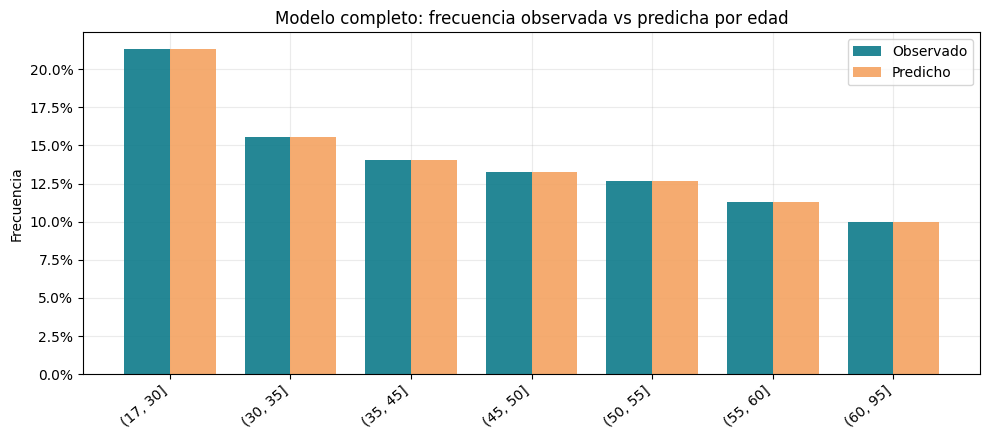

Ratio predicho/observado global: 1.0000  (ideal ~ 1.00)


In [11]:
# ── Validación: predicho vs observado por celda de edad ──────────────────────
datos['pred'] = modelo.predict(datos, offset=np.log(datos['exposicion']))
comp_edad = datos.groupby('edad_conductor_cat', observed=True).agg(
    obs=('num_siniestros','sum'), expo=('exposicion','sum'), pred=('pred','sum')).reset_index()
comp_edad['lo'] = comp_edad['edad_conductor_cat'].str.extract(r'\(([-0-9.]+),').astype(float)
comp_edad = comp_edad.sort_values('lo')
comp_edad['freq_obs'] = comp_edad['obs']/comp_edad['expo']
comp_edad['freq_pred'] = comp_edad['pred']/comp_edad['expo']

x = np.arange(len(comp_edad)); w=0.38
fig, ax = plt.subplots(figsize=(10,4.5))
ax.bar(x-w/2, comp_edad['freq_obs'],  w, label='Observado', color=AZUL, alpha=0.9)
ax.bar(x+w/2, comp_edad['freq_pred'], w, label='Predicho',  color=AMBAR, alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(comp_edad['edad_conductor_cat'], rotation=40, ha='right')
ax.set(ylabel='Frecuencia', title='Modelo completo: frecuencia observada vs predicha por edad')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.1%}'))
ax.legend(); plt.tight_layout(); plt.show()

ratio = datos['pred'].sum()/datos['num_siniestros'].sum()
print(f'Ratio predicho/observado global: {ratio:.4f}  (ideal ~ 1.00)')

### 📝 Ejercicio 3 — Offset ↔ weights, la misma historia (7 min)

- **3a.** Ajusta el modelo `num_siniestros ~ C(uso)` en sus dos formas: con `offset` y
  con `freq_weights`.
- **3b.** Muestra los coeficientes lado a lado y confirma que la diferencia máxima es ~0.
- **3c.** ¿Por qué en producción se prefiere el offset?

*Solución en `solucion_ejercicio3()`.*

In [ ]:
# Tu código aquí:


formula_uso = ('num_siniestros ~  C(uso)')

## forma 1 
modelo = smf.glm(formula_uso, datos, family=sm.families.Poisson(),
                 offset=np.log(datos['exposicion'])).fit()

---
# Bloque 5 · El supuesto de Poisson y las alternativas

Poisson trae incrustada la **equidispersión**: $\mathbb{E}[N\mid X]=\text{Var}[N\mid X]=\lambda$.
Si la varianza excede a la media hay **sobredispersión**, y sus causas son actuariales:
heterogeneidad no observada, dependencia entre siniestros del mismo asegurado, exceso
de ceros. La consecuencia es técnica y peligrosa: los **errores estándar se subestiman**,
los $p$-values se ven demasiado pequeños, y variables irrelevantes parecen significativas.

### De $s^2/\bar m$ al parámetro de Pearson — ¿por qué así?

Todo actuario calcula primero la dispersión como el **cociente de momentos**
$\hat\varphi=s^2/\bar m$ (varianza sobre media). Eso es correcto **cuando todas las
pólizas comparten la misma media**. Pero con covariables cada póliza tiene su propia
media ajustada $\hat\mu_i$, y una $\text{Var}/\text{Media}$ **global** mezclaría la
variación sistemática (la que explican las $\mathbf{x}$) con la dispersión aleatoria
que queremos medir.

La solución es estandarizar cada residuo por su **propia** varianza modelada — el
**residuo de Pearson** $r_i=\dfrac{y_i-\hat\mu_i}{\sqrt{V(\hat\mu_i)}}$, con $V(\mu)=\mu$
en Poisson. Entonces
$$\hat\varphi=\frac{1}{n-p}\sum_{i=1}^n r_i^2=\frac{1}{n-p}\sum_i\frac{(y_i-\hat\mu_i)^2}{\hat\mu_i}$$
es el promedio de las razones (desvío)²/varianza-modelada: **es $\text{Var}/\mathbb{E}$
generalizado** a que cada fila tiene su propia media. El puente que lo cierra: en el
modelo **solo-intercepto sobre conteos** ($\hat\mu=\bar y$) se reduce **exactamente** a
$s^2/\bar y$. Lo comprobamos:

In [12]:
# ── El puente: en conteos sin covariables, φ_Pearson == s²/ȳ (EXACTO) ────────
m_int = smf.glm('num_siniestros ~ 1', datos, family=sm.families.Poisson()).fit()
phi_pearson = np.sum(m_int.resid_pearson**2) / m_int.df_resid
ratio_momentos = datos['num_siniestros'].var(ddof=1) / datos['num_siniestros'].mean()
print(f'φ de Pearson (intercepto, sin offset): {phi_pearson:.6f}')
print(f's² / ȳ  (cociente de momentos)       : {ratio_momentos:.6f}')
print(f'¿Idénticos? {np.isclose(phi_pearson, ratio_momentos)}')
print('\nUna vez que agregas covariables/exposición, s²/ȳ global deja de ser válido')
print('y φ de Pearson es la generalización correcta.')

φ de Pearson (intercepto, sin offset): 1.090248
s² / ȳ  (cociente de momentos)       : 1.090248
¿Idénticos? True

Una vez que agregas covariables/exposición, s²/ȳ global deja de ser válido
y φ de Pearson es la generalización correcta.


Pendiente estimada (s²_N ~ 0 + m_N): 1.0845
Prueba H0: pendiente = 1  →  t = 12.04,  p = 0.0000


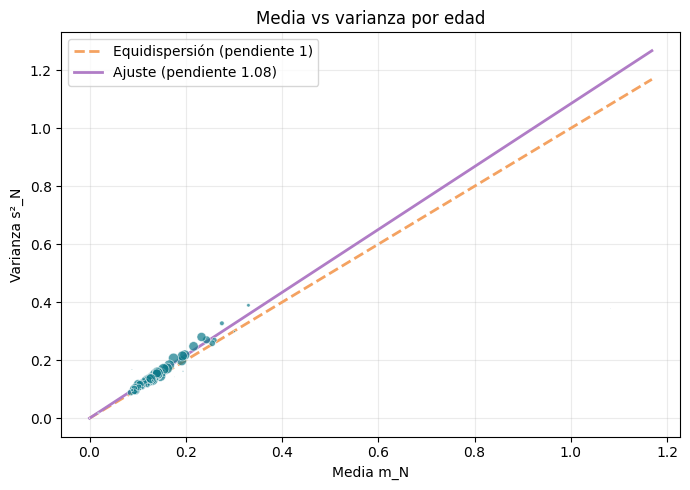

In [14]:
# ── La versión visual (grupo por grupo): media vs varianza + pendiente=1 ──────
def estad_grupo(g):
    e = g['exposicion'].sum(); m = g['num_siniestros'].sum()/e
    s2 = np.sum((g['num_siniestros'] - m*g['exposicion'])**2)/e
    return pd.Series({'m_N':m, 's2_N':s2, 'expo':e})

eda = datos.groupby('edad_conductor').apply(estad_grupo, include_groups=False).reset_index()

# Regresión sin intercepto s2_N ~ 0 + m_N ponderada por exposición.
# Bajo equidispersión la pendiente sería 1; una prueba formal contrasta H0: pendiente = 1.
reg = sm.WLS(eda['s2_N'], eda['m_N'], weights=eda['expo']).fit()
pend = reg.params.iloc[0]; t_stat = (pend - 1)/reg.bse.iloc[0]; p_val = 2*(1-stats.norm.cdf(abs(t_stat)))
print(f'Pendiente estimada (s²_N ~ 0 + m_N): {pend:.4f}')
print(f'Prueba H0: pendiente = 1  →  t = {t_stat:.2f},  p = {p_val:.4f}')

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(eda['m_N'], eda['s2_N'], s=eda['expo']/55, alpha=0.7, color=AZUL, edgecolors='white', linewidth=0.5, zorder=3)
lim = max(eda['m_N'].max(), eda['s2_N'].max())*1.08
ax.plot([0,lim],[0,lim],'--',color=AMBAR,lw=2,label='Equidispersión (pendiente 1)')
ax.plot([0,lim],[0,pend*lim],'-',color=MORADO,lw=2,label=f'Ajuste (pendiente {pend:.2f})')
ax.set(xlabel='Media m_N', ylabel='Varianza s²_N', title='Media vs varianza por edad')
ax.legend(); plt.tight_layout(); plt.show()

### La prueba formal: Cameron & Trivedi

El gráfico sugiere; una prueba de hipótesis decide. Cameron & Trivedi (1990) plantean
$$H_0:\ \text{Var}[N]=\mathbb{E}[N] \qquad\text{vs}\qquad H_1:\ \text{Var}[N]=\mathbb{E}[N]+\alpha\,\mathbb{E}[N],$$
y estiman $\alpha$ con una **regresión auxiliar** de $(y_i-\hat\mu_i)^2-y_i$ sobre
$\hat\mu_i$ (sin intercepto). Si $\alpha>0$ significativo, hay sobredispersión.

In [15]:
# ── Prueba de sobredispersión de Cameron-Trivedi ─────────────────────────────
m_edad = smf.glm('num_siniestros ~ edad_conductor', datos,
                 family=sm.families.Poisson(), offset=np.log(datos['exposicion'])).fit()
mu = m_edad.fittedvalues
u = (datos['num_siniestros'] - mu)**2 - datos['num_siniestros']   # (y-μ)² - y
aux = sm.OLS(u, mu).fit()                                          # u ~ 0 + μ
alpha, z, p = aux.params.iloc[0], aux.tvalues.iloc[0], aux.pvalues.iloc[0]
print(f'α estimado (sobredispersión): {alpha:.4f}')
print(f'Estadístico z: {z:.2f}   ·   p-value: {p:.4g}')
print('Conclusión:', 'SOBREDISPERSIÓN (rechazamos equidispersión)' if p<0.05 else 'no hay evidencia de sobredispersión')

phi = np.sum(m_edad.resid_pearson**2)/m_edad.df_resid
print(f'\nφ de Pearson del modelo: {phi:.4f}  →',
      'QuasiPoisson basta' if phi<1.5 else 'evalúa BN' if phi<2 else 'usa Binomial Negativa')

α estimado (sobredispersión): 0.0788
Estadístico z: 15.76   ·   p-value: 6.565e-56
Conclusión: SOBREDISPERSIÓN (rechazamos equidispersión)

φ de Pearson del modelo: 1.2101  → QuasiPoisson basta


### Las alternativas, en orden — y en qué cartera se usan

Cuando el diagnóstico marca sobredispersión, hay un menú. El orden en que los presentamos
va de "parche" a "modelo estructural":

1. **QuasiPoisson** — no es una distribución real; deja los coeficientes iguales y
   corrige los errores por $\sqrt{\phi}$. Para sobredispersión leve.
2. **ZIP** (Zero-Inflated Poisson) — dos poblaciones: una que **nunca** reclama (ceros
   estructurales) y otra Poisson. Para carteras con **exceso de ceros**: coberturas con
   deducibles altos donde muchos asegurados jamás presentan siniestro.
3. **Hurdle** — proceso de dos etapas: primero *¿hubo o no siniestro?* (logit), luego
   *dado que hubo, ¿cuántos?* (Poisson truncado en cero). Se prefiere cuando el
   mecanismo de "tener siniestro" es **distinto** al de "cuántos", y es fácil de explicar
   a la CNSF.
4. **Binomial Negativa** — mezcla Poisson-Gamma, $V(\mu)=\mu+\mu^2/\alpha$; modela
   **heterogeneidad no observada**. Para sobredispersión fuerte con muchos siniestros.

In [16]:
# ── 1) QuasiPoisson: mismos β, errores inflados por √φ ───────────────────────
m_pois  = smf.glm('num_siniestros ~ C(edad_conductor_cat)', datos,
                  family=sm.families.Poisson(), offset=np.log(datos['exposicion'])).fit()
m_quasi = smf.glm('num_siniestros ~ C(edad_conductor_cat)', datos,
                  family=sm.families.Poisson(), offset=np.log(datos['exposicion'])).fit(scale='X2')
comp_se = pd.DataFrame({'coef_pois':m_pois.params, 'SE_pois':m_pois.bse, 'SE_quasi':m_quasi.bse})
comp_se['inflación'] = comp_se['SE_quasi']/comp_se['SE_pois']
print(f'Escala QuasiPoisson (≈φ): {m_quasi.scale:.4f}  →  √φ = {np.sqrt(m_quasi.scale):.4f}')
print(comp_se.round(4).head().to_string())
print('Los coeficientes NO cambian; solo los errores estándar (× √φ).')

Escala QuasiPoisson (≈φ): 1.2050  →  √φ = 1.0977
                                   coef_pois  SE_pois  SE_quasi  inflación
Intercept                            -1.5444   0.0150    0.0164     1.0977
C(edad_conductor_cat)[T.(30, 35]]    -0.3180   0.0251    0.0276     1.0977
C(edad_conductor_cat)[T.(35, 45]]    -0.4181   0.0208    0.0229     1.0977
C(edad_conductor_cat)[T.(45, 50]]    -0.4747   0.0258    0.0283     1.0977
C(edad_conductor_cat)[T.(50, 55]]    -0.5219   0.0280    0.0307     1.0977
Los coeficientes NO cambian; solo los errores estándar (× √φ).


In [17]:
# ── 2) ZIP: prob. de ser "cero estructural" y su interpretación ──────────────
from statsmodels.discrete.count_model import ZeroInflatedPoisson
X = sm.add_constant(datos[['edad_conductor']].to_numpy(dtype=float))
zip_mod = ZeroInflatedPoisson(datos['num_siniestros'].to_numpy(dtype=float), X,
                              exog_infl=np.ones((len(datos),1)),
                              offset=np.log(datos['exposicion'].to_numpy(dtype=float))).fit(disp=0, maxiter=100)
p_estructural = 1/(1+np.exp(-zip_mod.params[0]))   # logit inverso del término de inflación
print(f'Probabilidad estimada de "cero estructural": {p_estructural:.3%}')
print('Interpretación: esa fracción de la cartera se modela como asegurados que')
print('nunca reclaman, aparte del proceso Poisson normal.')

Probabilidad estimada de "cero estructural": 35.358%
Interpretación: esa fracción de la cartera se modela como asegurados que
nunca reclaman, aparte del proceso Poisson normal.


In [18]:
# ── 3) Hurdle en dos etapas (transparente): logit + Poisson truncado ─────────
from statsmodels.discrete.truncated_model import TruncatedLFPoisson
# Etapa 1: ¿hubo al menos un siniestro?  (ocurrencia)
etapa1 = smf.glm('tiene_siniestro ~ edad_conductor', datos, family=sm.families.Binomial()).fit()
# Etapa 2: dado que hubo, ¿cuántos?  (conteo truncado en cero)
sub = datos[datos['num_siniestros'] > 0]
Xt = sm.add_constant(sub[['edad_conductor']].to_numpy(dtype=float))
etapa2 = TruncatedLFPoisson(sub['num_siniestros'].to_numpy(dtype=float), Xt).fit(disp=0, maxiter=200)
print('Hurdle = dos modelos independientes:')
print(f'  Etapa 1 (logit ocurrencia)   · coef edad = {etapa1.params.iloc[1]:+.4f}')
print(f'  Etapa 2 (Poisson truncado)   · coef edad = {etapa2.params[1]:+.4f}')
print('Ventaja: separa el "sí/no reclama" del "cuántos", cada uno con sus variables.')

Hurdle = dos modelos independientes:
  Etapa 1 (logit ocurrencia)   · coef edad = -0.0146
  Etapa 2 (Poisson truncado)   · coef edad = -0.0013
Ventaja: separa el "sí/no reclama" del "cuántos", cada uno con sus variables.


In [19]:
# ── 4) Binomial Negativa: V(μ)=μ+μ²/α, comparación por AIC ───────────────────
m_nb = smf.glm('num_siniestros ~ C(edad_conductor_cat)', datos,
               family=sm.families.NegativeBinomial(alpha=1.0),
               offset=np.log(datos['exposicion'])).fit()
tabla = pd.DataFrame({
    'modelo':['Poisson','Binomial Negativa'],
    'AIC':[m_pois.aic, m_nb.aic],
    'log-lik':[m_pois.llf, m_nb.llf],
})
print(tabla.to_string(index=False, float_format=lambda v: f'{v:,.1f}'))
print(f'\nMenor AIC = mejor. Aquí gana: {tabla.loc[tabla.AIC.idxmin(),"modelo"]}.')

           modelo       AIC   log-lik
          Poisson 126,365.6 -63,175.8
Binomial Negativa 126,061.0 -63,023.5

Menor AIC = mejor. Aquí gana: Binomial Negativa.


### 📝 Ejercicio 4 — ¿Qué familia para qué cartera? (12 min)

Te dan tres carteras hipotéticas. Para cada una, di qué distribución de frecuencia
usarías y por qué:

- **4a.** Cartera de autos con deducible muy alto: el 85% de asegurados nunca reclama.
- **4b.** Cartera de gastos médicos con clara heterogeneidad entre asegurados (φ ≈ 3).
- **4c.** Cartera de daños con sobredispersión leve (φ ≈ 1.3) donde el reporte a CNSF
  exige explicar por separado la probabilidad de siniestro.

Ajusta al menos una de ellas sobre `datos` y justifica con φ, AIC y sentido actuarial.

*Solución en `solucion_ejercicio4()`.*

In [ ]:
# Tu código aquí:


---
# Bloque 6 · Leer el `summary()` sin perderte

statsmodels devuelve ~40 números en tres bloques. Cada uno es un objeto matemático
concreto — y cada uno, un atributo accesible.

In [20]:
print(modelo.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         num_siniestros   No. Observations:               163212
Model:                            GLM   Df Residuals:                   163184
Model Family:                 Poisson   Df Model:                           27
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -62417.
Date:                Tue, 18 Aug 2026   Deviance:                       87143.
Time:                        16:47:21   Pearson chi2:                 1.90e+05
No. Iterations:                     6   Pseudo R-squ. (CS):            0.01663
Covariance Type:            nonrobust                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

| Elemento | Qué es (matemática) | Atributo | Señal de alarma 🚩 |
|---|---|---|---|
| `coef` | $\hat\beta_j$ (MLE, escala log) | `modelo.params` | signo contrario al sentido actuarial |
| `std err` | $\sqrt{[\mathcal I(\hat\beta)^{-1}]_{jj}}$ | `modelo.bse` | enorme → categoría con poca exposición |
| `z`, `P>\|z\|` | $\hat\beta_j/\text{SE}_j$ · Wald | `modelo.pvalues` | $p>0.05$ → nivel no difiere de la referencia |
| `[0.025, 0.975]` | IC 95%: $\hat\beta\pm1.96\,\text{SE}$ | `modelo.conf_int()` | $\exp$ del IC cruza 1 → RF no confiable |
| `Deviance` | $2(\ell_{\text{sat}}-\ell)$ | `modelo.deviance` | sube al quitar variable relevante |
| `Pearson chi2` | $\sum_i r_i^2$ | `modelo.pearson_chi2` | $/\,gl>1.5$ → sobredispersión |
| `AIC` | $-2\ell+2p$ | `modelo.aic` | para comparar modelos (Sesión 2) |

In [21]:
# ── Cada celda del summary es un atributo: reconstruimos φ y un RF con IC ─────
print('φ del modelo completo:', np.sum(modelo.resid_pearson**2)/modelo.df_resid)
ci = modelo.conf_int(); ci.columns = ['lo','hi']
termino = [t for t in modelo.params.index if 'nivel_bonus' in t][-1]
print(f'\nRating factor de "{termino}":')
print(f'  RF = {np.exp(modelo.params[termino]):.3f}   '
      f'IC95% = [{np.exp(ci.loc[termino,"lo"]):.3f}, {np.exp(ci.loc[termino,"hi"]):.3f}]   '
      f'p = {modelo.pvalues[termino]:.4g}')

φ del modelo completo: 1.1660559372162795

Rating factor de "C(nivel_bonus_cat)[T.(5, 10]]":
  RF = 1.699   IC95% = [1.628, 1.773]   p = 9.261e-130


### Python vs R — el mismo modelo, el mismo rigor

Lo mantenemos casi idéntico a propósito. No ejecutamos R aquí; la comparación a fondo
(incluida la estimación del parámetro de Tweedie) es la Sesión 2.

**Python — statsmodels**
```python
m   = smf.glm('num_siniestros ~ C(edad_cat) + C(cobertura)', datos,
              family=sm.families.Poisson(), offset=np.log(datos.exposicion)).fit()
np.exp(m.params)                                    # rating factors
# Cameron-Trivedi: OLS de (y-μ)²-y sobre μ
# ZIP:   ZeroInflatedPoisson(...).fit()
# Hurdle: logit + TruncatedLFPoisson(...)
# BN:    family=sm.families.NegativeBinomial()
```

**R — stats / AER / pscl / MASS**
```r
m <- glm(num_siniestros ~ edad_cat + cobertura, offset = log(exposicion),
         family = poisson, data = datos)
exp(coef(m))                                        # rating factors
AER::dispersiontest(m)                              # Cameron-Trivedi
pscl::zeroinfl(num_siniestros ~ edad | 1, ...)      # ZIP
pscl::hurdle(num_siniestros ~ edad | edad, ...)     # Hurdle
MASS::glm.nb(num_siniestros ~ edad_cat, ...)        # Binomial Negativa
```

| Concepto | Python | R |
|---|---|---|
| Offset | `offset=np.log(e)` | `offset = log(e)` |
| Rating factor | `np.exp(m.params)` | `exp(coef(m))` |
| Sobredispersión | OLS auxiliar | `AER::dispersiontest` |
| ZIP / Hurdle | `statsmodels.discrete` | `pscl::zeroinfl` / `hurdle` |
| Bin. Negativa | `families.NegativeBinomial` | `MASS::glm.nb` |

---
## 🎯 Ejercicio Integrador — Modelo de frecuencia, de principio a fin

Junta el flujo completo del día en un solo entregable, como en un proyecto real de pricing:

1. **EDA empírica** de las variables tarificadoras con IC 95%.
2. **Bandings** justificados para las continuas (revisa exposición por banda).
3. **Modelo completo** de frecuencia con offset y **todas** las variables.
4. **Diagnóstico**: φ de Pearson + Cameron-Trivedi. ¿Poisson basta o cambias de familia?
   Si hay sobredispersión, ajusta la alternativa que corresponda y compara por AIC.
5. **Rating factors** con IC 95% → `rating_factors_frecuencia.csv`.
6. **Puente empírico**: verifica en una variable que base×RF ≈ tasa empírica.
7. **Documenta** 3–4 líneas sobre los dos RF más fuertes, listos para nota técnica.

*Solución completa en `solucion_integrador()`.*

In [ ]:
# Scaffold — los bandings ya están arriba; complétalo tú.
# 1) EDA con tasa_empirica(...)   2) modelo full   3) φ + Cameron-Trivedi
# 4) alternativa si aplica  5) rating_factors(...).to_csv(...)  6) base×RF vs empírica

---
## Cierre — lo que llevas y lo que sigue

Hoy no solo ajustaste un GLM: entendiste **por qué** cada pieza es como es —el menú de
distribuciones ligado al pricing, la exposición como censura, φ como generalización de
Var/media, la prueba formal de sobredispersión, y el hecho de que el GLM **reproduce**
el cálculo empírico exacto antes de generalizarlo.

**Sesión 2 (26 ago):** la otra mitad de la prima pura — **severidad con Gamma** — y la
gran comparación **Poisson vs Gamma vs Tweedie** con **AIC, BIC y pseudo R²**, afinando
el contraste **Python vs R** hasta cómo cada lenguaje estima el parámetro $p$ de Tweedie.
Y al cerrar el tema: un **MCP** que interpreta las salidas del GLM por ti.